# OpenMP scaling analysis

Nur OpenMP / shared memory.

Parameter:
-    "wp":"real64"
-    "ratio_x":1
-    "ratio_y":1
-    "frames":100
-    "delta_frames":1
-    "periodicity":true
-    "preset":"random"


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('times.csv')

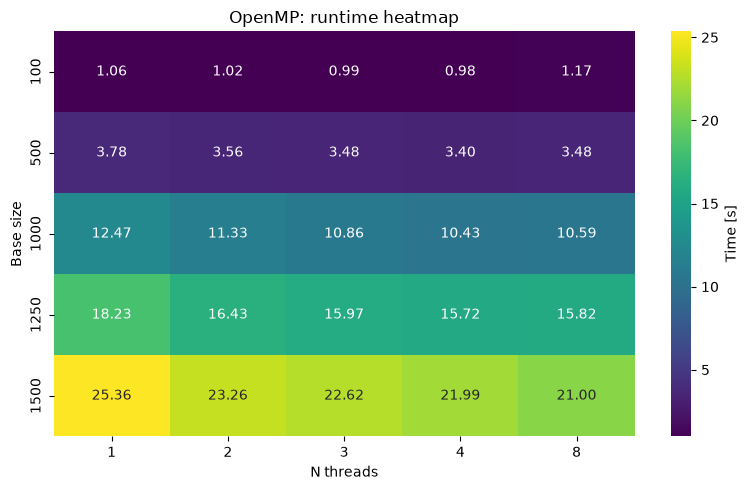

In [23]:
heat = df.pivot_table(index='base_size', columns='n_processes', values='time_s')
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': 'Time [s]'}, ax=ax)
ax.set_title('OpenMP: runtime heatmap')
ax.set_xlabel('N threads')
ax.set_ylabel('Base size')
plt.tight_layout()
plt.show()

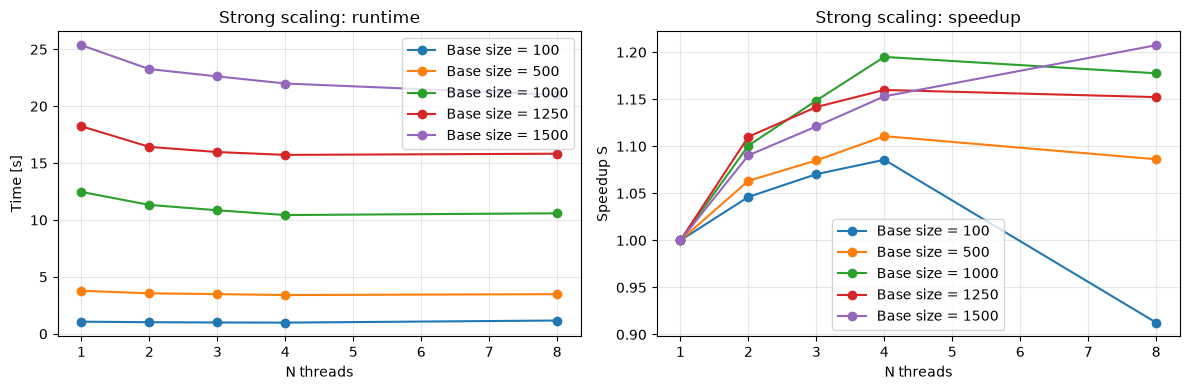

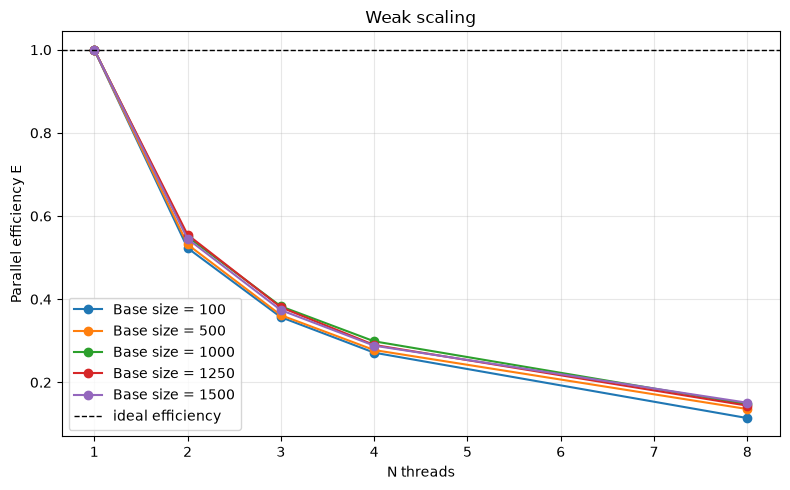

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for size, group in df.groupby('base_size'):
    group = group.sort_values('n_processes').copy()
    group['speedup'] = group['time_s'].iloc[0] / group['time_s']
    label = f'Base size = {size}'

    axes[0].plot(group['n_processes'], group['time_s'], marker='o', label=label)
    axes[1].plot(group['n_processes'], group['speedup'], marker='o', label=label)

axes[0].set_title('Strong scaling: runtime')
axes[0].set_xlabel('N threads')
axes[0].set_ylabel('Time [s]')
axes[1].set_title('Strong scaling: speedup')
axes[1].set_xlabel('N threads')
axes[1].set_ylabel('Speedup S')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))

for size, group in df.groupby('base_size'):
    group = group.sort_values('n_processes').copy()
    group['speedup'] = group['time_s'].iloc[0] / group['time_s']
    group['efficiency'] = group['speedup'] / group['n_processes']
    label = f'Base size = {size}'

    ax.plot(
        group['n_processes'],
        group['efficiency'],
        marker='o',
        label=label
    )

ax.set_title('Weak scaling')
ax.set_xlabel('N threads')
ax.set_ylabel('Parallel efficiency E')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='ideal efficiency')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()